# DiT 扩散训练架构详解

> 目标：把这个基于 Transformer 的扩散噪声预测架构讲清楚，并把笔记整理成一个不依赖项目内源文件、可以单独阅读和运行的版本。

这个笔记训练的并不是“直接生成图片”的模型，而是一个 **预测噪声的条件模型**。
给定：
- 原始图像 $x_0$
- 随机时间步 $t$
- 类别标签 $y$

先把 $x_0$ 加噪得到 $x_t$，再让模型学习预测当时加入的噪声 $\epsilon$。
训练目标是：

$$
\mathcal{L} = \mathbb{E}_{x_0, \epsilon, t} \left[ \|\epsilon - \epsilon_\theta(x_t, t, y)\|_1 \right]
$$

在这个笔记里，我们会把完整实现直接写在 notebook 中：
- 扩散前向加噪公式
- 时间嵌入 TimeEmbedding
- 条件化的 DiTBlock
- 完整的 DiT 主干
- 一个最小可运行的训练示例

可以把它理解成：
1. 扩散过程负责定义“怎样把图像逐步毁掉”。
2. DiT 负责学习“在任意时刻怎样把噪声估计出来”。
3. 采样时再把这个噪声预测器反复调用，实现从纯噪声逐步恢复图像。

## 1. 扩散训练到底在学什么

> 核心结论：模型看到的是加噪后的图像 $x_t$，学习的是“这张图里混入了多少噪声”。

前向扩散的闭式写法是：

$$
x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

这意味着训练时不需要真的一步一步加 1000 次噪声，只要随机抽一个时间步 $t$，就可以直接构造出该时刻的噪声图。
上面的完整实现单元里，forward_add_noise 就做了这件事。

为什么训练“预测噪声”而不是直接预测原图？
- 噪声目标分布更稳定。
- 不同时间步可以共享一个统一的学习目标。
- 反向采样公式天然依赖噪声估计值。

In [ ]:
import math
import torch

# -----------------------------
# 1. 扩散超参数
# -----------------------------
# T 表示扩散总步数，训练时会从 [0, T-1] 中随机采样一个时间步
T = 1000
betas = torch.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=-1)


def forward_add_noise(x, t):
    # 根据闭式公式，直接构造任意时间步 t 的加噪结果
    # x 的形状: (batch, channel, height, width)
    # t 的形状: (batch,)
    noise = torch.randn_like(x)

    # 为 batch 中每个样本取出对应时间步的 alpha_bar_t
    batch_alphas_cumprod = alphas_cumprod[t].view(x.size(0), 1, 1, 1)

    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    xt = torch.sqrt(batch_alphas_cumprod) * x + torch.sqrt(1 - batch_alphas_cumprod) * noise
    return xt, noise


# -----------------------------
# 2. 扩散加噪的数据流演示
# -----------------------------
# 构造一个假的 batch，说明训练时模型看到的到底是什么
x0 = torch.rand(4, 1, 28, 28)
x0 = x0 * 2 - 1                         # 先把像素范围映射到 [-1, 1]
t = torch.randint(0, T, (x0.size(0),))  # 每张图单独采样一个时间步

xt, noise = forward_add_noise(x0, t)

print('x0 shape   :', x0.shape)
print('t shape    :', t.shape)
print('xt shape   :', xt.shape)
print('noise shape:', noise.shape)

# 训练时，模型输入是 xt、t、y，监督信号是 noise。
# 也就是说，扩散模型主干做的是“条件噪声回归”。

## 2. 这个 DiT 主干是怎样替代 U-Net 的

> 这里的关键变化不是扩散公式变了，而是“预测噪声的网络”从卷积式 U-Net 换成了 Transformer。

在传统扩散模型里：
- 输入是 $x_t, t, y$
- 主干通常是 U-Net
- U-Net 依赖卷积、下采样、上采样和跳连来建模图像结构

在这个笔记里，我们不会立刻把完整 DiT 一次性写出来，而是按模块拆开理解：
1. 先看图像怎样变成 patch token。
2. 再看时间步和类别条件怎样注入。
3. 接着看 DiTBlock 如何用条件调制注意力和前馈层。
4. 最后再把这些模块组装成完整 DiT。

整个流程可以概括为：

$$
x_t \in \mathbb{R}^{B \times C \times H \times W}
\rightarrow \text{Patchify}
\rightarrow \text{Patch Embedding + Position Embedding}
\rightarrow \text{多层 DiTBlock}
\rightarrow \text{Linear 重建 patch}
\rightarrow \hat{\epsilon} \in \mathbb{R}^{B \times C \times H \times W}
$$

因此，DiT 的本质并不是“直接生成图像的 Transformer”，而是“用 Transformer 充当扩散模型的噪声预测器”。

In [ ]:
# 这一格先不实现完整 DiT，而是先把整体张量流转想清楚
batch_size = 2
img_size = 28
patch_size = 4
channel = 1
emb_size = 64

patch_count = img_size // patch_size
token_count = patch_count * patch_count

# 输入给 DiT 的是加噪图 x_t
xt = torch.rand(batch_size, channel, img_size, img_size)
print('input image shape :', xt.shape)

# 图像会先切成 patch，再变成 token 序列
print('patch count       :', patch_count, 'x', patch_count)
print('token count       :', token_count)
print('token shape       :', (batch_size, token_count, emb_size))

# DiT 处理完 token 后，还会把它们还原成和输入同尺寸的噪声图
print('output noise shape:', (batch_size, channel, img_size, img_size))

# 所以从接口上看，DiT 和 U-Net 一样，
# 都是接收 x_t、t、y，输出一个与图像同形状的噪声预测结果。

## 3. 图像是怎样变成 Transformer 能处理的 token 的

> Transformer 原本处理的是序列，所以图像必须先序列化。

在上面的 DiT 实现里，patchify 过程分成三步：
- 用卷积按 patch_size 切块
- 把每个 patch 拉直到一个向量
- 再映射到统一的 embedding 维度

这样一来，原始二维图像就变成了长度为 $N = (H / P) \times (W / P)$ 的 token 序列。

以本项目参数为例：
- 图像大小是 $28 \times 28$
- patch 大小是 $4 \times 4$
- patch 数量近似看作 $7 \times 7 = 49$ 个 token

之后再加上位置编码，让模型知道每个 patch 原来位于图像的哪里。

In [ ]:
import torch
from torch import nn

# 下面这段代码对应 dit.py 的 patchify 主逻辑，并补上了解释性注释
img_size = 28
patch_size = 4
channel = 1
emb_size = 64

patch_count = img_size // patch_size
conv = nn.Conv2d(
    in_channels=channel,
    out_channels=channel * patch_size ** 2,
    kernel_size=patch_size,
    stride=patch_size,
    padding=0,
 )
patch_emb = nn.Linear(channel * patch_size ** 2, emb_size)
patch_pos_emb = torch.rand(1, patch_count ** 2, emb_size)

x = torch.rand(2, 1, 28, 28)

# 第一步：按 patch 大小切分图像
# conv 的输出通道数是 channel * patch_size ** 2，等于每个 patch 展平后的维度
# conv 的 kernel_size 和 stride 都是 patch_size，这样就能把图像切成不重叠的 patch
# 输入形状: (batch, channel, height, width)
# 输出形状: (batch, patch 展平后的通道数, patch_count, patch_count)
x = conv(x)
print('after conv       :', x.shape)

# 第二步：把空间网格整理成 token 序列
# 输入形状: (batch, patch 展平后的通道数, patch_count, patch_count)
# permute 的作用是把通道维放到最后，变成 (batch, patch_count, patch_count, patch 展平后的通道数)，
# 这样就能把每个 patch 的特征当成一个 token 来处理了
x = x.permute(0, 2, 3, 1)
# 输出形状: (batch, patch_count, patch_count, patch 展平后的通道数)
# view 的作用是把空间维度展平，变成 (batch, patch_count * patch_count, patch 展平后的通道数)，
# 这样就得到了一个 patch token 序列，每个 token 的维度是 patch 展平后的通道数
x = x.view(x.size(0), patch_count * patch_count, x.size(3))
print('as patch tokens  :', x.shape)

# 第三步：把每个 patch 投影到统一的 embedding 空间
# 输入形状: (batch, patch_count * patch_count, patch 展平后的通道数)
# patch_emb 的作用是把每个 patch token 从原始维度投影到 emb_size 维度，这样后续的 Transformer block 就能处理了
x = patch_emb(x)
# patch_pos_emb 是一个可学习的位置编码，直接加到 token 上，提供位置信息
x = x + patch_pos_emb
# 输出形状: (batch, patch_count * patch_count, emb_size)
print('token embedding  :', x.shape)

# 到这里，二维图像已经被转成 Transformer 可处理的序列表示。

## 4. 时间步和类别信息是怎样注入到 Transformer 里的

> 扩散模型不是只看图像，它还必须知道“现在是第几步去噪”以及“想生成哪一类”。

本项目把条件分成两部分：
- 时间嵌入 $t \rightarrow t_{emb}$
- 类别嵌入 $y \rightarrow y_{emb}$

然后直接相加得到条件向量：

$$
cond = t_{emb} + y_{emb}
$$

下面先实现时间嵌入模块，再把时间条件和类别条件拼起来。
这个条件向量不会像文本条件那样通过 cross-attention 注入，而是通过 DiTBlock 内部的 adaLN 风格调制作用在特征上。

In [ ]:
from torch import nn

class TimeEmbedding(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        self.half_emb_size = emb_size // 2

        # 这里构造的是一组固定频率，后面会和时间步 t 相乘
        half_emb = torch.exp(
            torch.arange(self.half_emb_size) * (-math.log(10000) / (self.half_emb_size - 1))
        )
        self.register_buffer('half_emb', half_emb)

    def forward(self, t):
        # t 的形状: (batch,) -> (batch, 1)
        t = t.view(t.size(0), 1)

        # 扩展成 (batch, half_emb_size)，让每个样本都能和频率向量逐元素相乘
        half_emb = self.half_emb.unsqueeze(0).expand(t.size(0), self.half_emb_size)
        half_emb_t = half_emb * t

        # 拼接 sin 和 cos，得到最终时间嵌入
        return torch.cat((half_emb_t.sin(), half_emb_t.cos()), dim=-1)


emb_size = 64
label_num = 10
batch_size = 4

time_encoder = nn.Sequential(
    TimeEmbedding(emb_size),
    nn.Linear(emb_size, emb_size),
    nn.ReLU(),
    nn.Linear(emb_size, emb_size),
)
label_emb = nn.Embedding(num_embeddings=label_num, embedding_dim=emb_size)

# 生成随机时间步和随机类别标签
t = torch.randint(0, T, (batch_size,))
y = torch.randint(0, label_num, (batch_size,))

# 时间条件和类别条件都会变成 emb_size 维向量
t_emb = time_encoder(t)
y_emb = label_emb(y)
cond = t_emb + y_emb

print('t_emb shape  :', t_emb.shape)
print('y_emb shape  :', y_emb.shape)
print('cond shape   :', cond.shape)

# cond 是每个样本一个条件向量，后面会用于调制 DiTBlock 内部特征。

## 5. DiTBlock 为什么是这个模型最关键的部分

> 这一层决定了：条件信息怎样影响注意力和前馈网络。

在这个实现中，DiTBlock 做了两次条件调制：
- 第一次在自注意力前
- 第二次在前馈网络前

它的思路是：
1. 先对 token 做 LayerNorm。
2. 用条件向量生成缩放和偏移参数。
3. 调整归一化后的特征分布。
4. 再送入 Attention 或 FFN。

下面先把 DiTBlock 单独实现出来，再观察一层 block 的输入输出形状。
这和经典 Transformer 最大的不同在于：
- 标准 Transformer 的 LayerNorm 参数是固定的。
- 这里的 LayerNorm 由条件向量动态控制。

In [ ]:
from torch import nn

class DiTBlock(nn.Module):
    def __init__(self, emb_size, nhead):
        super().__init__()
        self.emb_size = emb_size
        self.nhead = nhead

        # 条件调制参数：分别作用在 attention 分支和 FFN 分支
        self.gamma1 = nn.Linear(emb_size, emb_size)
        self.beta1 = nn.Linear(emb_size, emb_size)
        self.alpha1 = nn.Linear(emb_size, emb_size)
        self.gamma2 = nn.Linear(emb_size, emb_size)
        self.beta2 = nn.Linear(emb_size, emb_size)
        self.alpha2 = nn.Linear(emb_size, emb_size)

        self.ln1 = nn.LayerNorm(emb_size)
        self.ln2 = nn.LayerNorm(emb_size)

        # 这里沿用原项目中的实现方式：每个 head 使用完整 emb_size 维度
        self.wq = nn.Linear(emb_size, nhead * emb_size)
        self.wk = nn.Linear(emb_size, nhead * emb_size)
        self.wv = nn.Linear(emb_size, nhead * emb_size)
        self.lv = nn.Linear(nhead * emb_size, emb_size)

        self.ff = nn.Sequential(
            nn.Linear(emb_size, emb_size * 4),
            nn.ReLU(),
            nn.Linear(emb_size * 4, emb_size),
        )

    def forward(self, x, cond):
        # 输入的x是 patch token 序列，形状是 (batch, token_count, emb_size)
        # cond是时间编码和标签编码的加和，形状: (batch, emb_size)
        # alpha1、alpha2 控制 attention 分支和 FFN 分支输出进入残差的强弱
        alpha1_val = self.alpha1(cond)
        alpha2_val = self.alpha2(cond)
        # gamma1、beta1 和 gamma2、beta2 分别控制两处条件调制的缩放和平移
        gamma1_val = self.gamma1(cond)
        beta1_val = self.beta1(cond)

        gamma2_val = self.gamma2(cond)
        beta2_val = self.beta2(cond)
        # 输出形状: (batch, emb_size)

        # 第一处条件调制：先归一化，再根据条件做缩放和平移
        # LayerNorm 的输入输出形状都是 (batch, token_count, emb_size)，它会沿着最后一个维度做归一化
        y = self.ln1(x)
        # gamma1 和 beta1 控制 attention 分支输入的特征分布，alpha1 控制 attention 分支输出进入残差的强弱
        # 公式：out= y*（1+gamma）+beta，gamma 控制缩放，beta 控制平移
        # 实际上就是做一个线性映射，权重是(1+gamma),偏置是 beta
        # 形状广播：gamma1_val 和 beta1_val 的形状是 (batch, emb_size)，需要 unsqueeze(1) 变成 (batch, 1, emb_size)，
        # 这样才能和 y 的形状 (batch, token_count, emb_size)
        y = y * (1 + gamma1_val.unsqueeze(1)) + beta1_val.unsqueeze(1)
        # 调制的作用是让模型根据条件动态调整特征分布，增强模型的表达能力和适应性。

        # 自注意力：让任意两个 patch token 直接交互
        # (batch, token_count, emb_size)-> (batch, token_count, nhead * emb_size)
        q = self.wq(y)
        k = self.wk(y)
        v = self.wv(y)
        # (batch, token_count, nhead , emb_size) -> (batch, nhead, token_count, emb_size)
        q = q.view(q.size(0), q.size(1), self.nhead, self.emb_size).permute(0, 2, 1, 3)
        # (batch, token_count, nhead , emb_size) -> (batch,  nhead ,token_count, emb_size)
        k = k.view(k.size(0), k.size(1), self.nhead, self.emb_size).permute(0, 2, 1, 3)
        # (batch, token_count, nhead , emb_size) -> (batch, nhead, token_count, emb_size)
        v = v.view(v.size(0), v.size(1), self.nhead, self.emb_size).permute(0, 2, 1, 3)

        attn = q @ k / math.sqrt(q.size(2))
        attn = torch.softmax(attn, dim=-1)
        y = attn @ v
        # y 的形状是 (batch, nhead, token_count, emb_size)，需要把 nhead 和 emb_size 维度合并回去
        y = y.permute(0, 2, 1, 3)
        # y 的形状是 (batch, token_count, nhead * emb_size)，需要通过线性层投影回 emb_size 维度
        y = y.reshape(y.size(0), y.size(1), y.size(2) * y.size(3))
        # 最后通过线性层把维度变回 emb_size，输出形状是 (batch, token_count, emb_size)
        y = self.lv(y)

        # alpha1 控制 attention 分支输出进入残差的强弱
        y = x + y * alpha1_val.unsqueeze(1)

        # 第二处条件调制：作用在前馈网络前
        z = self.ln2(y)
        z = z * (1 + gamma2_val.unsqueeze(1)) + beta2_val.unsqueeze(1)
        # (batch, token_count, emb_size)
        # 前馈网络：每个 token 独立处理，没有交互，增强非线性表达能力
        z = self.ff(z)
        z = z * alpha2_val.unsqueeze(1)
        return y + z


# 用一个最小示例观察 DiTBlock 的输入输出
block = DiTBlock(emb_size=16, nhead=4)
x = torch.rand(2, 49, 16)   # 49 个 patch token
cond = torch.rand(2, 16)    # 每个样本一个条件向量

out = block(x, cond)
print('input token shape :', x.shape)
print('cond shape        :', cond.shape)
print('block output shape:', out.shape)

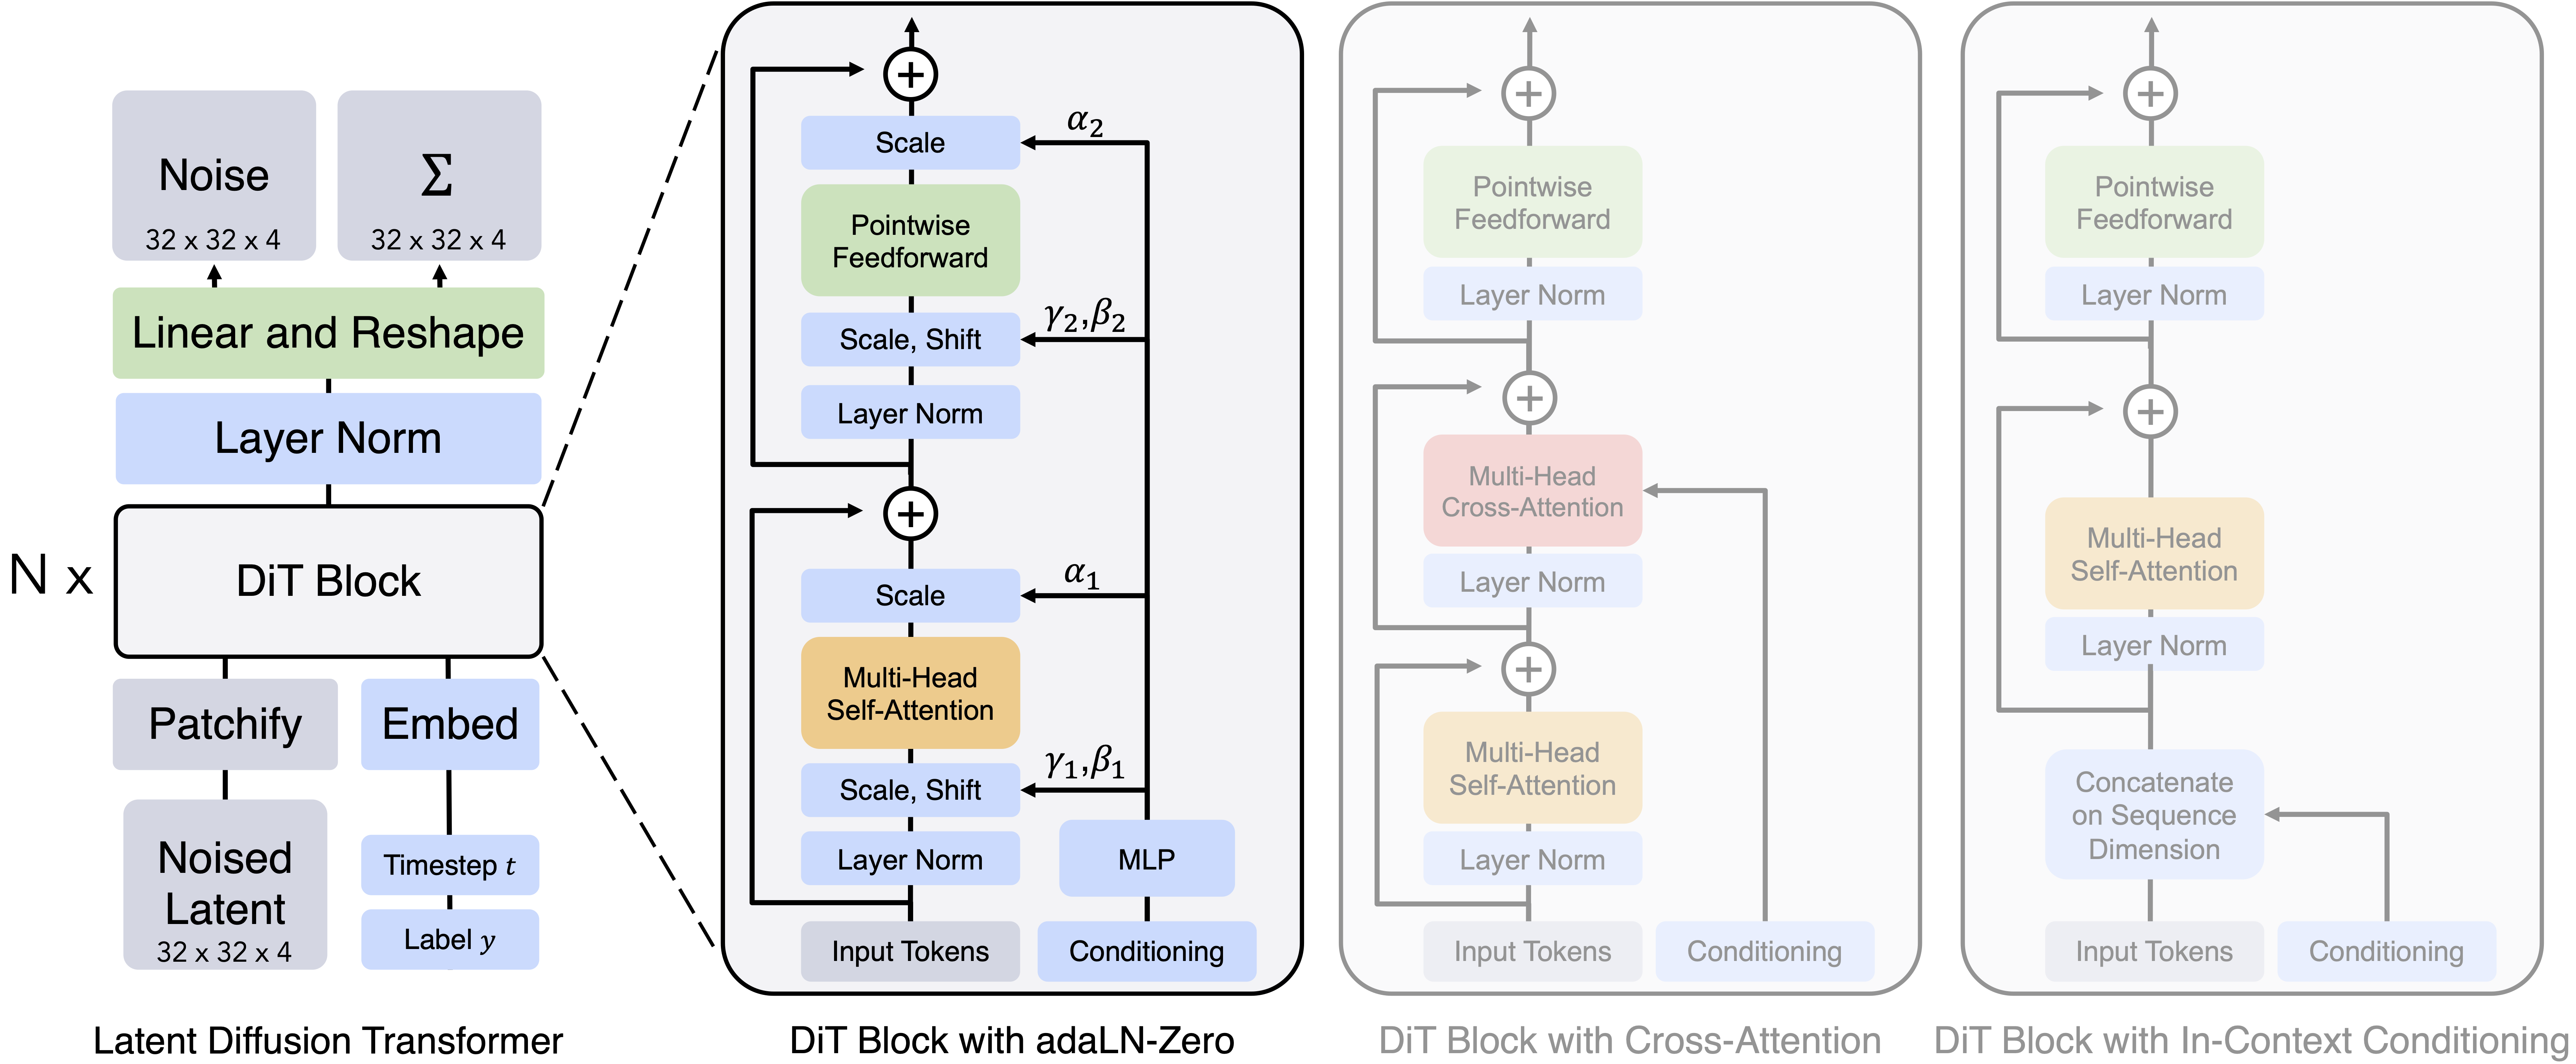

## 6. 训练代码如何把这些模块串起来

> 到这里，扩散加噪、时间嵌入和 DiTBlock 都已经单独看过了。现在把它们组装成完整 DiT，再看一次训练时的数据流。

训练循环可以概括为：
1. 从数据集中取出原图 $x_0$ 和标签 $y$。
2. 把像素范围从 $[0, 1]$ 映射到 $[-1, 1]$。
3. 为每张图随机采样时间步 $t$。
4. 用扩散公式得到加噪图 $x_t$ 和真实噪声 $\epsilon$。
5. 把 $x_t, t, y$ 输入 DiT，得到预测噪声 $\hat{\epsilon}$。
6. 用损失函数约束 $\hat{\epsilon}$ 接近 $\epsilon$。

这个笔记使用的是 L1Loss：

$$
\mathcal{L} = \|\hat{\epsilon} - \epsilon\|_1
$$

下面这格代码会先定义完整 DiT，再走一遍最小训练示例。

In [ ]:
from torch import nn

class DiT(nn.Module):
    def __init__(self, img_size, patch_size, channel, emb_size, label_num, dit_num, head):
        super().__init__()
        self.patch_size = patch_size
        self.patch_count = img_size // patch_size
        self.channel = channel

        # 先把图像切成 patch，并把每个 patch 展平成向量
        self.conv = nn.Conv2d(
            in_channels=channel,
            out_channels=channel * patch_size ** 2,
            kernel_size=patch_size,
            padding=0,
            stride=patch_size,
        )
        self.patch_emb = nn.Linear(channel * patch_size ** 2, emb_size)
        self.patch_pos_emb = nn.Parameter(torch.rand(1, self.patch_count ** 2, emb_size))

        # 时间条件和类别条件分别编码，再相加融合
        self.time_emb = nn.Sequential(
            TimeEmbedding(emb_size),
            nn.Linear(emb_size, emb_size),
            nn.ReLU(),
            nn.Linear(emb_size, emb_size),
        )
        self.label_emb = nn.Embedding(num_embeddings=label_num, embedding_dim=emb_size)

        # 多层 DiTBlock 负责在条件控制下建模 token 之间的关系
        self.dits = nn.ModuleList([DiTBlock(emb_size, head) for _ in range(dit_num)])
        self.ln = nn.LayerNorm(emb_size)
        self.linear = nn.Linear(emb_size, channel * patch_size ** 2)

    def forward(self, x, t, y):
        # 1. 构造条件向量
        y_emb = self.label_emb(y)
        t_emb = self.time_emb(t)
        cond = y_emb + t_emb

        # 2. 图像 -> patch token
        x = self.conv(x)
        x = x.permute(0, 2, 3, 1)
        x = x.view(x.size(0), self.patch_count * self.patch_count, x.size(3))
        x = self.patch_emb(x)
        x = x + self.patch_pos_emb

        # 3. 多层 DiTBlock 处理 token 序列
        for dit in self.dits:
            x = dit(x, cond)

        # 4. token -> patch -> 图像，输出噪声预测结果
        # 形状：(1) x 的形状是 (batch, token_count, emb_size)，需要先归一化，再通过线性层投影回 patch 展平后的维度
        x = self.ln(x)
        x = self.linear(x)
        # 形状：(2) x 的形状是 (batch, token_count, patch 展平后的维度)，需要先把 token_count 还原成空间维度，再把 patch 展平后的维度还原成通道维度
        x = x.view(
            x.size(0),
            self.patch_count,
            self.patch_count,
            self.channel,
            self.patch_size,
            self.patch_size,
        )
        # (batch, patch_count, patch_count, channel, patch_size, patch_size)
        x = x.permute(0, 3, 1, 2, 4, 5)
        # (batch, channel, patch_count, patch_count, patch_size, patch_size)
        x = x.permute(0, 1, 2, 4, 3, 5)
        # (batch, channel, patch_count, patch_size, patch_count, patch_size)
        x = x.reshape(
            x.size(0),
            self.channel,
            self.patch_count * self.patch_size,
            self.patch_count * self.patch_size,
        )
        # (batch, channel, img_size, img_size)
        return x


# 这是最小可运行的训练流程示例，直接依赖 notebook 中已经定义好的模块
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DiT(
    img_size=28,
    patch_size=4,
    channel=1,
    emb_size=64,
    label_num=10,
    dit_num=3,
    head=4,
).to(device)

loss_fn = nn.L1Loss()

# 这里用随机张量代替 DataLoader 输出，目的是把训练数据流讲清楚
batch_size = 8
img_size = 28
channel = 1
num_classes = 10
imgs = torch.rand(batch_size, channel, img_size, img_size)
labels = torch.randint(0, num_classes, (batch_size,))

# 1. 把图像映射到 [-1, 1]，和高斯噪声尺度更匹配
x0 = imgs * 2 - 1

# 2. 随机采样时间步：同一个 batch 内，不同样本可以处于不同噪声强度
t = torch.randint(0, T, (imgs.size(0),))

# 3. 按时间步构造加噪图和真实噪声
xt, noise = forward_add_noise(x0, t)

# 4. 用 DiT 预测噪声
pred_noise = model(xt.to(device), t.to(device), labels.to(device))

# 5. 让预测噪声逼近真实噪声
loss = loss_fn(pred_noise, noise.to(device))
print('pred_noise shape:', pred_noise.shape)
print('training loss   :', float(loss))

## 7. 相比 U-Net，DiT 的优势是什么

> 先说结论：DiT 的主要优势不在“小模型更省”，而在“扩展性更强、统一性更好、长程建模能力更自然”。

### 7.1 DiT 的优势

> 1. 更擅长全局关系建模

> U-Net 依赖局部卷积逐层扩大感受野；Transformer 的自注意力可以直接让任意两个 patch 交互。
这在图像分辨率更高、结构关系更复杂时，通常比纯卷积更容易学习全局一致性。

> 2. 架构更统一，扩展更直接

> U-Net 常常需要手工设计不同尺度的通道数、下采样层、上采样层和跳连结构。
DiT 的扩展路径更像语言模型：
- 增大 embedding 维度
- 增加 block 层数
- 增加头数
- 调整 patch 大小

这种扩展方式更规则，通常更适合做大模型。

> 3. 条件注入更自然

> 在这个项目里，时间步和类别条件通过 adaLN 风格直接调制每层表示。
相比把条件只塞进输入端，或者在某些层做拼接，DiT 这种“层层调制”的方式更系统。

> 4. 更容易和其他 Transformer 生态兼容

> 如果后续要接文本、多模态条件、预训练 token 表示，Transformer 主干通常更容易对接。
这也是很多大规模生成模型偏向 Transformer 主干的重要原因。

### 7.2 U-Net 仍然强在哪里

> 1. 对中小规模图像任务通常更高效

> 卷积天然带有局部归纳偏置，在数据量不大、图像分辨率不高时，U-Net 往往更省参数、更稳。

> 2. 计算复杂度通常更友好

> 注意力对 token 数敏感，图像越大，patch 越多，Transformer 成本上升越明显。
而卷积在很多视觉任务上仍然是非常强的工程基线。

> 3. 小数据集下更容易训练

> MNIST 这种任务本身很简单，所以这里用 DiT 是为了理解架构思想。
如果目标只是快速得到一个能用的扩散生成器，U-Net 通常仍是更朴素、成功率更高的选择。

### 7.3 一句话对比

> U-Net 的强项是视觉归纳偏置强、训练稳定、工程效率高；
DiT 的强项是全局建模和扩展性更强，在大模型和大数据条件下潜力更高。

## 8. 结合这个仓库，应该怎样理解它的训练架构

> 把整个项目压缩成一句话：

这个仓库训练的是一个 **条件 DiT 噪声预测器**，流程如下：
1. 用扩散公式把 MNIST 图片加噪到随机时间步。
2. 用时间嵌入和数字标签嵌入构造条件向量。
3. 把加噪图像切成 patch token。
4. 用多层 DiTBlock 在条件控制下建模 token 之间的关系。
5. 输出和输入同尺寸的噪声预测图。
6. 用真实噪声监督训练。

所以它和 U-Net 版扩散模型的根本区别只有一个：
- 扩散训练目标没变。
- 反向采样公式没变。
- 变的是“负责预测噪声的神经网络结构”。

如果你把这一点抓住，就不会把“DiT”误解成一种完全不同的扩散模型。
它只是把卷积骨干换成了 Transformer 骨干。

一般来说，作为动作生成的diffusion，会使用条件生成模型，也就是说，将完备的状态state(不是观测，而是考虑时间信息的隐变量，能够实现MDP)作为条件，然后生成在这个条件下的动作，所以训练时输入就是动作向量，